# Replicate: Nvidia AI IOT NanoSAM
### .onnx (onnxruntime-gpu)
July 29th

NanoSAM is a Segment Anything (SAM) model variant that is capable of running in 🔥 real-time 🔥 on NVIDIA Jetson Orin Platforms with NVIDIA TensorRT.

In [1]:
"""
# clean env wipe & activate
conda env remove --name nanosam_arm64 -y
conda deactivate
conda create -n nanosam_arm64 python=3.10 -y
conda activate nanosam_arm64

sudo apt update
sudo apt install libcudnn8 libcudnn8-dev
conda install -c conda-forge libstdcxx-ng=12 -y

"""

'\n# clean env wipe & activate\nconda env remove --name nanosam_arm64 -y\nconda deactivate\nconda create -n nanosam_arm64 python=3.10 -y\nconda activate nanosam_arm64\n\nsudo apt update\nsudo apt install libcudnn8 libcudnn8-dev\nconda install -c conda-forge libstdcxx-ng=12 -y\n\n'

In [2]:
"""
# Installation of nanosam_arm64 repo requirements

git clone https://github.com/NVIDIA-AI-IOT/nanosam
cd nanosam
python3 setup.py develop --user


# More requirements
pip install timm==1.0.17 ultralytics==8.0.120 matplotlib==3.5.3 'opencv-python<4.9' jetson-stats


# Typical np version mismatch
pip uninstall -y numpy
pip install "numpy>=1.19.2,<2.0"
# pip install numpy==1.26.4 

# Now install the CUDA PyTorch 2.5.0a0 (compatible with jp61 torch)
pip install --no-cache https://developer.download.nvidia.com/compute/redist/jp/v61/pytorch/torch-2.5.0a0+872d972e41.nv24.08.17622132-cp310-cp310-linux_aarch64.whl

# download torchvision 0.20.0a0 (compatible with jp61 torch)
cd ~/vision/
python3 setup.py install
cd ~

# --- ONNXRUNTIME-GPU (build from scratch) ------------- #

cd ~/onnxruntime
pip uninstall onnxruntime -y
pip install build/Linux/Release/dist/onnxruntime_gpu-*.whl --force-reinstall
pip install sympy==1.13.1 numpy==1.26.4

"""

# Debug Support

# Check your conda env GLIBCXX versions
# strings /home/copter/miniconda3/envs/nanosam_arm64/lib/python3.10/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6 | grep GLIBCXX

# trt2torch is apparently an issue and is obsolete for trt --version=10.3.0 
# additionally `pip install pycuda`

'\n# Installation of nanosam_arm64 repo requirements\n\ngit clone https://github.com/NVIDIA-AI-IOT/nanosam\ncd nanosam\npython3 setup.py develop --user\n\n\n# More requirements\npip install timm==1.0.17 ultralytics==8.0.120 matplotlib==3.5.3 \'opencv-python<4.9\' jetson-stats\n\n\n# Typical np version mismatch\npip uninstall -y numpy\npip install "numpy>=1.19.2,<2.0"\n# pip install numpy==1.26.4 \n\n# Now install the CUDA PyTorch 2.5.0a0 (compatible with jp61 torch)\npip install --no-cache https://developer.download.nvidia.com/compute/redist/jp/v61/pytorch/torch-2.5.0a0+872d972e41.nv24.08.17622132-cp310-cp310-linux_aarch64.whl\n\n# download torchvision 0.20.0a0 (compatible with jp61 torch)\ncd ~/vision/\npython3 setup.py install\ncd ~\n\n# --- ONNXRUNTIME-GPU (build from scratch) ------------- #\n\ncd ~/onnxruntime\npip uninstall onnxruntime -y\npip install build/Linux/Release/dist/onnxruntime_gpu-*.whl --force-reinstall\npip install sympy==1.13.1 numpy==1.26.4\n\n'

In [1]:
# from nanosam.utils.predictor import Predictor
import onnxruntime as ort
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


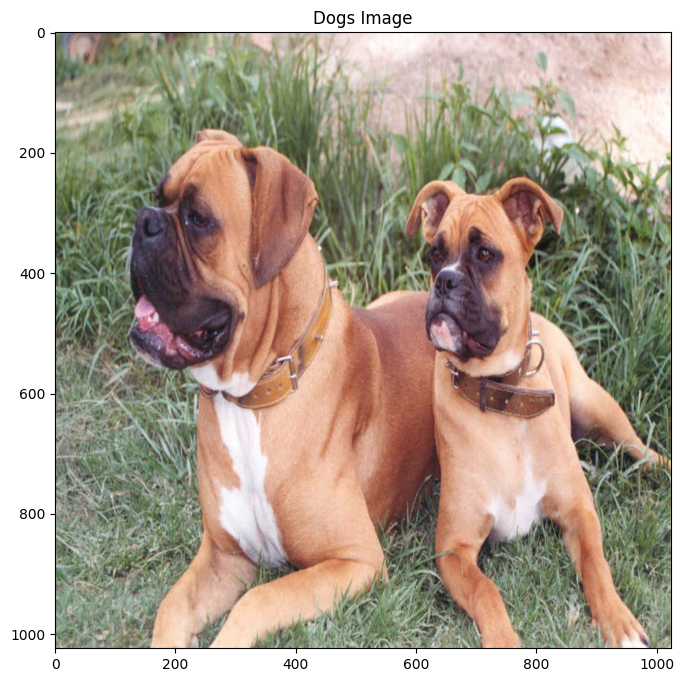

In [2]:
# Load the image
# image = PIL.open("/home/copter/jetson_benchmark/images/dogs.jpg")
image_path = "/home/copter/jetson_benchmark/images/dogs.jpg"
img = Image.open(image_path).convert("RGB")
img = img.resize((1024, 1024), resample=Image.BILINEAR)
w, h = img.size  # now both are 1024

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('on')  # Hide axes for cleaner display
plt.title("Dogs Image")
plt.show()

In [3]:
encoder_model_path="/home/copter/onnx_models/nvidia_ai_iot_resnet18_image_encoder.onnx"
decoder_model_path="/home/copter/onnx_models/nvidia_ai_iot_mobile_sam_mask_decoder.onnx"

In [4]:
# Check available Execution Providers
print("--- Checking Available Execution Providers ---")
available_providers = ort.get_available_providers()
print(f"Available ONNX Runtime Execution Providers: {available_providers}")


# Set providers
preferred_providers = ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

# Configure session options (for threading)
session_options = ort.SessionOptions()
session_options.intra_op_num_threads = 6
session_options.inter_op_num_threads = 1
session_options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL

try:
    print(f"Attempting to load encoder model with providers: {preferred_providers}")
    enc_sess = ort.InferenceSession(encoder_model_path, providers=preferred_providers, sess_options=session_options)
    print(f"Encoder session loaded. Actual provider used: {enc_sess.get_providers()}")

    print(f"Attempting to load decoder model with providers: {preferred_providers}")
    dec_sess = ort.InferenceSession(decoder_model_path, providers=preferred_providers, sess_options=session_options)
    print(f"Decoder session loaded. Actual provider used: {dec_sess.get_providers()}")

    # Verify which provider was actually chosen by ONNX Runtime
    if 'TensorrtExecutionProvider' in enc_sess.get_providers() and \
       'TensorrtExecutionProvider' in dec_sess.get_providers():
        print("✅ ONNX models successfully loaded and are using TensorrtExecutionProvider.")
    elif 'CUDAExecutionProvider' in enc_sess.get_providers() and \
         'CUDAExecutionProvider' in dec_sess.get_providers():
        print("✅ ONNX models successfully loaded and are using CUDAExecutionProvider (TensorRT not available or failed).")
    else:
        print("⚠️ ONNX models loaded successfully with CPUExecutionProvider (neither TensorRT nor CUDA available or failed).")

except Exception as e:
    print(f"An error occurred during session creation with preferred providers: {e}")
    # Fallback to CPU if preferred providers fail entirely
    print("Falling back to CPUExecutionProvider for both models.")
    try:
        enc_sess = ort.InferenceSession(encoder_model_path, providers=['CPUExecutionProvider'], sess_options=session_options)
        dec_sess = ort.InferenceSession(decoder_model_path, providers=['CPUExecutionProvider'], sess_options=session_options)
        print("⚠️ ONNX models loaded successfully with CPUExecutionProvider !!")
    except Exception as cpu_e:
        print(f"Fatal Error: Could not load models even with CPUExecutionProvider: {cpu_e}")

--- Checking Available Execution Providers ---
Available ONNX Runtime Execution Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Attempting to load encoder model with providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Encoder session loaded. Actual provider used: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Attempting to load decoder model with providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Decoder session loaded. Actual provider used: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
✅ ONNX models successfully loaded and are using TensorrtExecutionProvider.


2025-08-04 15:09:05.988275089 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:531 RegisterTensorRTPluginsAsCustomOps] The custom op domain name trt.plugins is already in session option.


In [ ]:
# # --- Model Loading and Initial Memory Measurement ---
# preferred_providers = ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
# enc_sess = None
# dec_sess = None

# try:
#     print(f"Attempting to load encoder model with providers: {preferred_providers}")
#     enc_sess = ort.InferenceSession(encoder_model_path, providers=preferred_providers)
#     print(f"Encoder session loaded. Actual provider used: {enc_sess.get_providers()}")

#     print(f"Attempting to load decoder model with providers: {preferred_providers}")
#     dec_sess = ort.InferenceSession(decoder_model_path, providers=preferred_providers)
#     print(f"Decoder session loaded. Actual provider used: {dec_sess.get_providers()}")

#     # Verify which provider was actually chosen by ONNX Runtime
#     if 'TensorrtExecutionProvider' in enc_sess.get_providers() and \
#        'TensorrtExecutionProvider' in dec_sess.get_providers():
#         print("✅ ONNX models successfully loaded and are using TensorrtExecutionProvider.")
#     elif 'CUDAExecutionProvider' in enc_sess.get_providers() and \
#          'CUDAExecutionProvider' in dec_sess.get_providers():
#         print("✅ ONNX models successfully loaded and are using CUDAExecutionProvider (TensorRT not available or failed).")
#     else:
#         print("⚠️ ONNX models loaded successfully with CPUExecutionProvider (neither TensorRT nor CUDA available or failed).")

# except Exception as e:
#     print(f"An error occurred during session creation with preferred providers: {e}")
#     # Fallback to CPU if preferred providers fail entirely
#     print("Falling back to CPUExecutionProvider for both models.")
#     try:
#         enc_sess = ort.InferenceSession(encoder_model_path, providers=['CPUExecutionProvider'])
#         dec_sess = ort.InferenceSession(decoder_model_path, providers=['CPUExecutionProvider'])
#         print("⚠️ ONNX models loaded successfully with CPUExecutionProvider !!")
#     except Exception as cpu_e:
#         print(f"Fatal Error: Could not load models even with CPUExecutionProvider: {cpu_e}")
#         # Ensure jtop is closed even in case of fatal error
#         jetson.close()
#         print("\njtop closed...")
#         exit() # Exit if models cannot be loaded at all

# # Create a dummy image for demonstration (adjust dimensions if needed for your model)
# # Assuming typical SAM input dimensions
# h, w = 1024, 1024
# img = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)

# # Capture memory right after models are loaded
# loaded_models_memory = jetson.memory['RAM']['used'] / (1024**3) # in GB
# loaded_models_memory_mb = loaded_models_memory * 1024 # in MB

# print(f"\nMemory after models loaded (Encoder & Decoder): {loaded_models_memory:.2f} GB ({loaded_models_memory_mb:.2f} MB)")

In [5]:
# ---- PRIMITIVE INFERENCE DEMO (in MS) ------------------------------- # 

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import onnxruntime as ort
import os

# 1) Inspect exactly which inputs the mask‐decoder wants:
for inp in dec_sess.get_inputs():
    print(inp.name, inp.shape, inp.type)

# 2) Normalize & transpose input image to NCHW
img_arr = np.array(img).astype(np.float32) / 255.0  # image --> arr
input_image = img_arr.transpose(2, 0, 1)[None, :, :, :]     #  traspose arr

image_embeddings [1, 256, 64, 64] tensor(float)
point_coords [1, 'num_points', 2] tensor(float)
point_labels [1, 'num_points'] tensor(float)
mask_input [1, 1, 256, 256] tensor(float)
has_mask_input [1] tensor(float)


In [ ]:
# ENCODER: Run the encoder (H, W are supposed to be 1024 x 1024)
enc_input_name = enc_sess.get_inputs()[0].name

# Produce image embeddings
image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]


# ----------- MODEL PROMPT --------------------- #

# # 4) Assume image_embeddings is already float32
# point_coords = np.array([[[w/2, h/2]]], dtype=np.float32)    # <-- Point Prompt: was already float32
# point_labels = np.array([[1]],           dtype=np.float32)   # <-- Point labels, 1 = foreground, 0 = background

# # dummy “previous mask” inputs must be float32
# dummy_mask_input     = np.zeros((1, 1, 256, 256), dtype=np.float32)
# dummy_has_mask_input = np.zeros((1,        ), dtype=np.float32)  # <— float32

# # bundle by name
# dec_input_names = [inp.name for inp in dec_sess.get_inputs()]
# dec_inputs = {
#     dec_input_names[0]: image_embeddings,
#     dec_input_names[1]: point_coords,
#     dec_input_names[2]: point_labels,
#     dec_input_names[3]: dummy_mask_input,
#     dec_input_names[4]: dummy_has_mask_input,
# }

# # DECODE: Unpack mask outputs
# mask_out, scores = dec_sess.run(None, dec_inputs)
# print("Decoder outputs:")
# for out in dec_sess.get_outputs():
#     print(f"  {out.name}: {out.shape}")

# # 2) Run and unpack correctly
# raw_outs = dec_sess.run(None, dec_inputs)
# # raw_outs[0].shape == (1, 4) → that's scores
# # raw_outs[1].shape == (1, 4, 256, 256) → that's mask_out
# scores, mask_out = raw_outs

# ---- PRIMITIVE INFERENCE DEMO (in MS) ------------------------------- # 

def segment_everything_with_grid(img, enc_sess, dec_sess, image_embeddings, grid_size=32):
    """
    Segment everything by sampling points on a grid
    """
    # Get decoder input names
    dec_input_names = [inp.name for inp in dec_sess.get_inputs()]
    
    h, w = img.size[1], img.size[0]  # PIL image dimensions
    
    # Create grid of points (default it the full screen)
    x_coords = np.linspace(0, w-1, grid_size)
    y_coords = np.linspace(0, h-1, grid_size)
    
    all_masks = []
    all_scores = []
    
    # Sample points on grid (skip some to avoid too many)
    for x in x_coords[::4]:  
        for y in y_coords[::4]:
            # Create point prompt
            point_coords = np.array([[[x, y]]], dtype=np.float32)
            point_labels = np.array([[1]], dtype=np.float32)
            
            # Dummy inputs
            dummy_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
            dummy_has_mask_input = np.zeros((1,), dtype=np.float32)
            
            # Prepare decoder inputs
            dec_inputs = {
                dec_input_names[0]: image_embeddings,
                dec_input_names[1]: point_coords,
                dec_input_names[2]: point_labels,
                dec_input_names[3]: dummy_mask_input,
                dec_input_names[4]: dummy_has_mask_input,
            }
            
            # Run decoder
            scores, mask_out = dec_sess.run(None, dec_inputs)
            
            # Take best mask (highest score)
            best_idx = np.argmax(scores[0])
            if scores[0, best_idx] > 0.5:  # Quality threshold
                all_masks.append(mask_out[0, best_idx])
                all_scores.append(scores[0, best_idx])
    
    return all_masks, all_scores

# Usage:
all_masks, all_scores = segment_everything_with_grid(img, enc_sess, dec_sess, image_embeddings)
print(f"Found {len(all_masks)} masks")

# # 3) Print shapes & count
# print("all_masks shape:", all_masks.shape)   # should be (1, N, H, W)
# print("mask_out (single mask) shape:", all_masks[0].shape)   # should be (1, N, H, W)
# print("all_scores   shape:", all_scores.shape)     # should be (1, N)
# n_masks = all_masks.shape[1]
# print("number of masks predicted:", n_masks)

Found 64 masks


Used 20 masks out of 64 (threshold: 0.8)


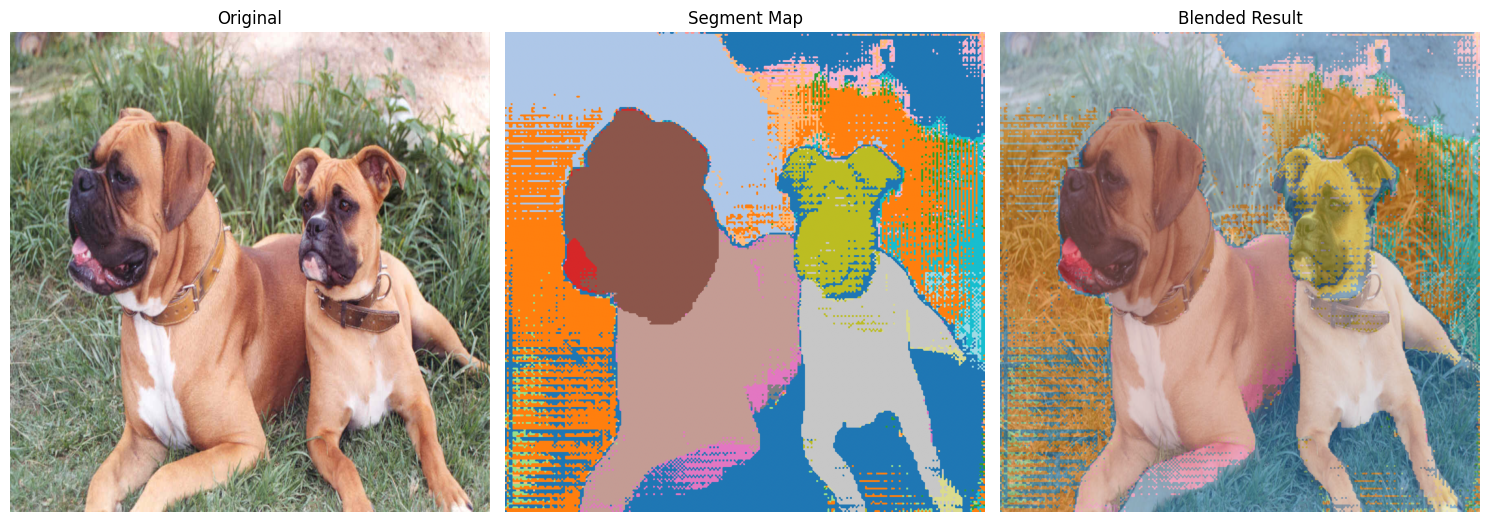

In [13]:
# Create a segmentation map where each pixel gets a unique segment ID
img_array = np.array(img)
h, w = img_array.shape[:2]
segment_map = np.zeros((h, w), dtype=np.int32)

# Set score threshold
score_threshold = 0.8  # Adjust this value as needed

# Filter masks by score and assign each a unique ID
segment_id = 1  # Start from 1 (0 is background)
for mask, score in zip(all_masks, all_scores):
    # Skip masks below threshold
    if score < score_threshold:
        continue
        
    binary_mask = mask > 0
    
    # Resize mask if needed
    if binary_mask.shape != (h, w):
        from PIL import Image
        mask_pil = Image.fromarray((binary_mask * 255).astype(np.uint8))
        mask_pil = mask_pil.resize((w, h))
        binary_mask = np.array(mask_pil) > 128
    
    # Only assign to pixels that aren't already assigned (first mask wins)
    segment_map[binary_mask & (segment_map == 0)] = segment_id
    segment_id += 1

print(f"Used {segment_id - 1} masks out of {len(all_masks)} (threshold: {score_threshold})")

# Create colorful visualization
plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segment_map, cmap='tab20')  # Use a colorful colormap
plt.title("Segment Map")
plt.axis('off')

plt.subplot(1, 3, 3)
# Blend original image with colorful segments
colored_segments = plt.cm.tab20(segment_map / segment_map.max())[:,:,:3]
blended = img_array * 0.5 + colored_segments * 255 * 0.5
plt.imshow(blended.astype(np.uint8))
plt.title("Blended Result")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ---- Mask Selection and Display ------------------------ #

# 1) Pick the best mask
scores_flat = scores.flatten()
best_idx    = int(np.argmax(scores_flat))
print(f"Best mask idx: {best_idx}   score: {scores_flat[best_idx]:.3f}")

# 2) Extract, threshold, and resize the mask
raw_mask  = mask_out[0, best_idx]            # (H_mask,W_mask) in [0,1]
binary    = (raw_mask > 0.5).astype(np.uint8) * 255
mask_img  = Image.fromarray(binary)
mask_rs   = mask_img.resize((w, h), Image.BILINEAR)

# 3) Build a 20%‑opaque red overlay
#    Take the 0–255 mask and scale it to 0–51 (≈20% of 255)
alpha_mask = mask_rs.point(lambda p: int(p * 0.3))
red_layer  = Image.new("RGBA", (w, h), (255, 0, 0, 0))
red_layer.putalpha(alpha_mask)

# 4) Composite over the original
base_rgba  = img.convert("RGBA")
composited = Image.alpha_composite(base_rgba, red_layer)

# 5) Plot with a star at the prompt point
star_x, star_y = point_coords[0, 0]
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(composited)
ax.scatter(star_x, star_y, marker="*", color="yellow", s=200)
ax.axis("on")


In [ ]:
# ---- MAIN TIMING BENCH (in MS) ------------------------------- # 

import time
from jtop import jtop # Import the jtop library

# -----------------------------------------

# Initialize jtop
# It's best to do this once and close it when you're done
jetson = jtop()
jetson.start()

def get_gpu_memory():
    # Access GPU-specific memory usage from the jtop stats
    # jtop provides values in bytes, so we convert to GB
    return jetson.memory['RAM']['used'] / (1024**3)

try:
    # Get baseline
    baseline_memory = get_gpu_memory()
    peak_memory = baseline_memory

    # 1) Inspect exactly which inputs the mask‐decoder wants:
    print("\nDecoder Inputs:")
    for inp in dec_sess.get_inputs():
        print(inp.name, inp.shape, inp.type)

    # 2) Normalize & transpose input image to NCHW
    img_arr = np.array(img).astype(np.float32) / 255.0  # image --> arr
    input_image = img_arr.transpose(2, 0, 1)[None, :, :, :]     #  traspose arr

    print("\nPerforming warm-up runs...")
    # Warm-up runs for both encoder and decoder
    for _ in range(5):
        # ENCODER warm-up
        enc_input_name = enc_sess.get_inputs()[0].name
        image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]

        # Decoder inputs warm-up (needs to be prepared for warm-up)
        point_coords = np.array([[[w/2, h/2]]], dtype=np.float32)
        point_labels = np.array([[1]], dtype=np.float32)
        dummy_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
        dummy_has_mask_input = np.zeros((1,), dtype=np.float32)

        dec_input_names = [inp.name for inp in dec_sess.get_inputs()]
        dec_inputs = {
            dec_input_names[0]: image_embeddings,
            dec_input_names[1]: point_coords,
            dec_input_names[2]: point_labels,
            dec_input_names[3]: dummy_mask_input,
            dec_input_names[4]: dummy_has_mask_input,
        }
        # DECODER warm-up
        _ = dec_sess.run(None, dec_inputs)
        peak_memory = max(peak_memory, get_gpu_memory())
    print("Warm-up complete.")

    num_runs = 50
    full_pipeline_times = []
    decoder_only_times = []
    
    print(f"\nStarting {num_runs} inference runs...")

    for i in range(num_runs):
        # --- Full Inference Pipeline Benchmark ---
        start_time_full = time.time()

        # ENCODER: Run the encoder (H, W are supposed to be 1024 x 1024)
        enc_input_name = enc_sess.get_inputs()[0].name
        image_embeddings = enc_sess.run(None, {enc_input_name: input_image})[0]

        # 4) Assume image_embeddings is already float32
        point_coords = np.array([[[w/2, h/2]]], dtype=np.float32)    # was already float32
        point_labels = np.array([[1]],           dtype=np.float32)   # changed from int64

        # dummy “previous mask” inputs must be float32
        dummy_mask_input     = np.zeros((1, 1, 256, 256), dtype=np.float32)
        dummy_has_mask_input = np.zeros((1,        ), dtype=np.float32)  # <— float32

        # bundle by name
        dec_input_names = [inp.name for inp in dec_sess.get_inputs()]
        dec_inputs = {
            dec_input_names[0]: image_embeddings,
            dec_input_names[1]: point_coords,
            dec_input_names[2]: point_labels,
            dec_input_names[3]: dummy_mask_input,
            dec_input_names[4]: dummy_has_mask_input,
        }
        
        # --- Decoder Only Benchmark ---
        start_time_decoder = time.time()
        # DECODE: Unpack mask outputs
        mask_out, scores = dec_sess.run(None, dec_inputs)
        end_time_decoder = time.time()
        decoder_only_times.append(end_time_decoder - start_time_decoder)
        # --- End Decoder Only Benchmark ---

        end_time_full = time.time()
        full_pipeline_times.append(end_time_full - start_time_full)
        # --- End Full Inference Pipeline Benchmark ---

        # Check memory after each inference
        current_memory = get_gpu_memory()
        current_memory_mb = 1000 * current_memory

        peak_memory = max(peak_memory, current_memory)
        peak_memory_mb = 1000 * peak_memory
        
        if (i + 1) % 10 == 0:
            print(f" Run {i+1}/{num_runs} completed. Current GPU memory: {current_memory:.2f} GB, ({current_memory_mb:.2f} MB)")

    average_full_pipeline_time_ms = (sum(full_pipeline_times) / num_runs) * 1000
    average_decoder_only_time_ms = (sum(decoder_only_times) / num_runs) * 1000

    print(f"\nAverage Full Pipeline Inference Speed (Encoder + Decoder ONNX CUDA): {average_full_pipeline_time_ms:.2f} ms per image")
    print(f"Average Decoder Only Inference Speed (ONNX CUDA): {average_decoder_only_time_ms:.2f} ms per image")
    
    # You might want to print shapes from a single run for clarity
    print(f"Raw ONNX mask_out prediction shape: {mask_out.shape}")
    print(f"Raw ONNX scores prediction shape: {scores.shape}")

    print(f"\nBaseline GPU memory: {baseline_memory:.2f} GB")
    print(f"Peak GPU memory usage: {peak_memory:.2f} GB  ({peak_memory_mb:.2f} MB)")
    print(f"Memory increase: {peak_memory - baseline_memory:.2f} GB")

finally:
    # Always make sure to close the jtop instance to release resources
    jetson.close()
    print("\njtop closed...")